PCA-Based Statistical Factor Risk Model for Portfolio Risk Decomposition and Market Risk Measurement

**Objective:**  
To develop a statistical factor risk model using Principal Component Analysis (PCA) to identify common drivers of equity returns, estimate factor exposures, decompose portfolio risk into systematic and idiosyncratic components, and evaluate market risk using Value at Risk (VaR), Expected Shortfall (ES), Sharpe Ratio and Diversification Ratio.

**Tools:** Python, R, MATLAB/Octave  
**Primary Environment:** Google Colab  
**Data Source:** Yahoo Finance via yfinance

In [5]:
!pip -q install yfinance

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import chi2
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
tickers = [
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "ITC.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "SUNPHARMA.NS",
    "MARUTI.NS",
    "HINDUNILVR.NS",
    "ADANIPORTS.NS"
]

stock_names = {
    "HDFCBANK.NS": "HDFC Bank",
    "ICICIBANK.NS": "ICICI Bank",
    "RELIANCE.NS": "Reliance",
    "TCS.NS": "TCS",
    "INFY.NS": "Infosys",
    "ITC.NS": "ITC",
    "LT.NS": "L&T",
    "BHARTIARTL.NS": "Bharti Airtel",
    "SUNPHARMA.NS": "Sun Pharma",
    "MARUTI.NS": "Maruti Suzuki",
    "HINDUNILVR.NS": "HUL",
    "ADANIPORTS.NS": "Adani Ports"
}

# Equal-weighted portfolio
weights = np.repeat(1 / len(tickers), len(tickers))

weights_df = pd.DataFrame({
    "Ticker": tickers,
    "Company": [stock_names[t] for t in tickers],
    "Weight": weights
})

weights_df

,Ticker,Company,Weight
0,HDFCBANK.NS,HDFC Bank,0.083333
1,ICICIBANK.NS,ICICI Bank,0.083333
2,RELIANCE.NS,Reliance,0.083333
3,TCS.NS,TCS,0.083333
4,INFY.NS,Infosys,0.083333
5,ITC.NS,ITC,0.083333
6,LT.NS,L&T,0.083333
7,BHARTIARTL.NS,Bharti Airtel,0.083333
8,SUNPHARMA.NS,Sun Pharma,0.083333
9,MARUTI.NS,Maruti Suzuki,0.083333


In [8]:
start_date = "2021-01-01"

prices = yf.download(
    tickers,
    start=start_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna(axis=1, how="all")
prices = prices.ffill().dropna()

print("Data downloaded successfully.")
print("Number of observations:", len(prices))
print("Number of stocks:", len(prices.columns))

prices.tail()

Data downloaded successfully.
Number of observations: 1403
Number of stocks: 12


Ticker,ADANIPORTS.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,MARUTI.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,,,,,,,
2026-08-25,1702.699951,1947.000000,727.500000,2024.199951,1422.699951,1144.000000,271.399994,4119.000000,13678.000000,1317.000000,1922.000000,2296.199951
2026-08-26,1691.500000,1902.099976,727.200012,2021.000000,1430.000000,1120.000000,270.250000,4038.100098,13520.000000,1298.000000,1899.500000,2270.000000
2026-08-27,1714.000000,1878.300049,711.000000,2009.000000,1443.000000,1110.800049,269.000000,4027.000000,13440.000000,1282.199951,1913.300049,2248.399902
2026-08-28,1707.500000,1882.400024,720.299988,2010.400024,1422.800049,1144.000000,266.000000,4045.800049,13376.000000,1287.000000,1913.300049,2342.000000
2026-08-31,1593.099976,1811.900024,709.000000,1967.400024,1454.000000,1133.800049,255.500000,4044.899902,13547.000000,1277.000000,1984.800049,2399.300049


In [9]:
prices.columns = [stock_names.get(col, col) for col in prices.columns]

print("Stocks included:")
for col in prices.columns:
    print("-", col)

Stocks included:
- Adani Ports
- Bharti Airtel
- HDFC Bank
- HUL
- ICICI Bank
- Infosys
- ITC
- L&T
- Maruti Suzuki
- Reliance
- Sun Pharma
- TCS


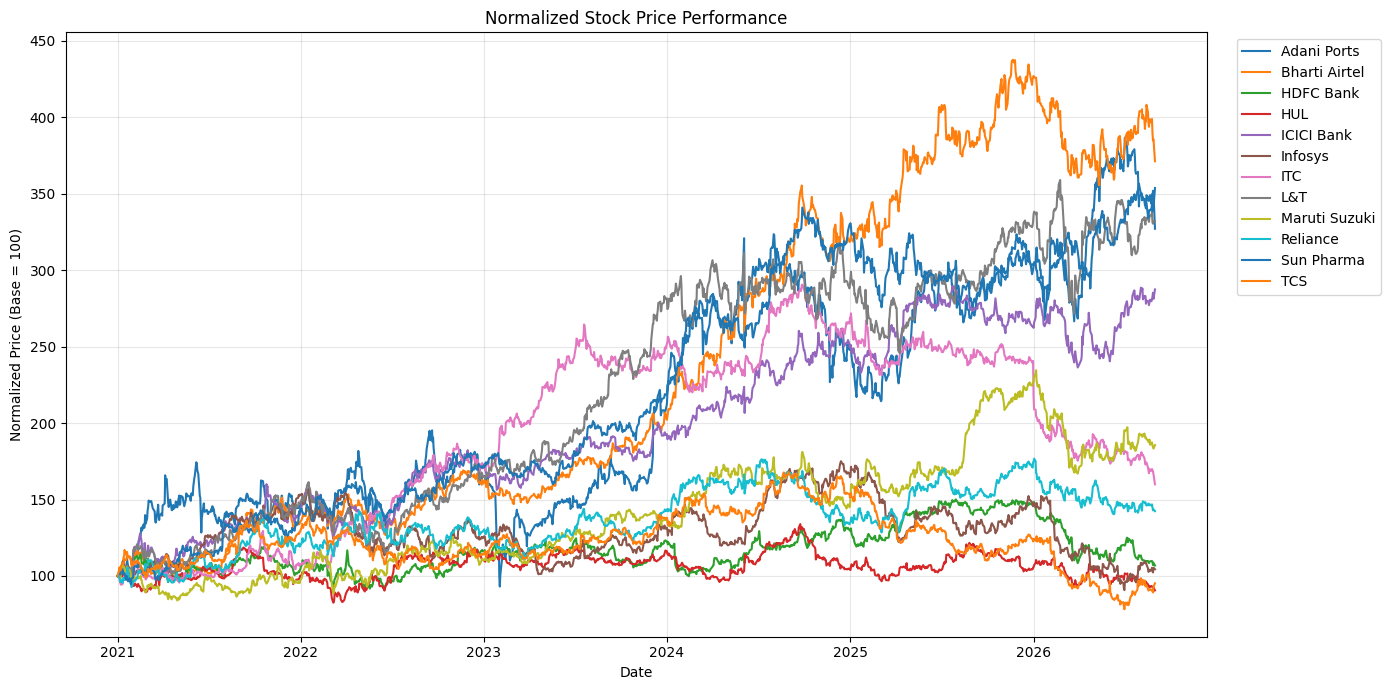

In [10]:
plt.figure(figsize=(14, 7))

for column in prices.columns:
    normalized = prices[column] / prices[column].iloc[0] * 100
    plt.plot(normalized, label=column)

plt.title("Normalized Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
returns = prices.pct_change().dropna()

print("Return dataset shape:", returns.shape)

returns.head()

Return dataset shape: (1402, 12)


,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Date,,,,,,,,,,,,
2021-01-04,-0.009824,0.003785,-0.006351,0.016314,0.007962,0.022055,-0.002104,0.013570,0.001430,0.001685,0.013668,0.037975
2021-01-05,0.001102,-0.005995,0.007556,0.009911,0.010438,0.004308,-0.009138,-0.006314,-0.006082,-0.012432,-0.001572,0.017618
2021-01-06,-0.005306,0.021984,-0.004311,-0.013568,0.017590,-0.009043,-0.028612,0.005894,-0.003507,-0.026372,0.003066,-0.013417
2021-01-07,0.034320,0.037978,-0.003027,-0.020043,-0.010243,-0.015560,-0.012658,0.018988,-0.008199,-0.001619,-0.005617,-0.006128
2021-01-08,0.006130,-0.009170,0.010874,0.009435,0.001756,0.039575,-0.006410,0.025729,0.059324,0.011799,0.031400,0.029049


In [12]:
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)

summary_stats = pd.DataFrame({
    "Annualized Return": annual_return,
    "Annualized Volatility": annual_volatility,
    "Minimum Daily Return": returns.min(),
    "Maximum Daily Return": returns.max()
})

summary_stats.sort_values("Annualized Volatility", ascending=False)

,Annualized Return,Annualized Volatility,Minimum Daily Return,Maximum Daily Return
Adani Ports,0.284550,0.375121,-0.211497,0.153019
Infosys,0.039750,0.252846,-0.094227,0.079340
L&T,0.246188,0.246800,-0.126746,0.085525
Maruti Suzuki,0.138861,0.235778,-0.065990,0.087508
Reliance,0.089194,0.226955,-0.074851,0.070192
Bharti Airtel,0.261120,0.225024,-0.065703,0.070272
TCS,0.016221,0.224100,-0.083861,0.066328
ICICI Bank,0.213824,0.219895,-0.076336,0.124395
HDFC Bank,0.035227,0.216472,-0.084358,0.100133
Sun Pharma,0.248956,0.209359,-0.045527,0.100924


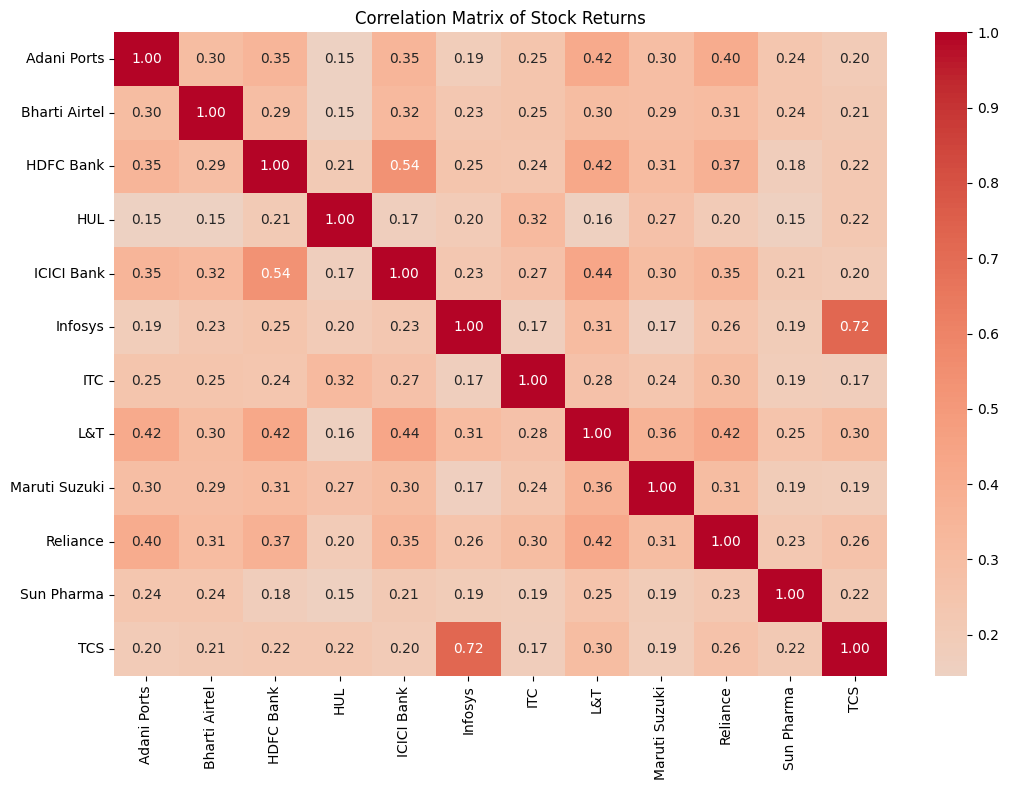

In [13]:
corr_matrix = returns.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Stock Returns")
plt.tight_layout()
plt.show()

In [14]:
cov_matrix_daily = returns.cov()
cov_matrix_annual = cov_matrix_daily * 252

cov_matrix_annual

,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Adani Ports,0.140716,0.025514,0.028162,0.011269,0.028702,0.017654,0.018891,0.038436,0.026359,0.034426,0.018872,0.016855
Bharti Airtel,0.025514,0.050636,0.014176,0.006735,0.015962,0.013079,0.011404,0.016884,0.015333,0.015661,0.011253,0.010718
HDFC Bank,0.028162,0.014176,0.046860,0.009261,0.025511,0.013479,0.010424,0.022667,0.015857,0.018250,0.007964,0.010911
HUL,0.011269,0.006735,0.009261,0.042341,0.007564,0.010528,0.013501,0.007977,0.012956,0.009343,0.006546,0.010307
ICICI Bank,0.028702,0.015962,0.025511,0.007564,0.048354,0.012929,0.011994,0.023693,0.015785,0.017219,0.009894,0.009729
Infosys,0.017654,0.013079,0.013479,0.010528,0.012929,0.063931,0.008811,0.019119,0.009854,0.014697,0.010294,0.040953
ITC,0.018891,0.011404,0.010424,0.013501,0.011994,0.008811,0.041479,0.013831,0.011559,0.013887,0.007968,0.007954
L&T,0.038436,0.016884,0.022667,0.007977,0.023693,0.019119,0.013831,0.060910,0.020905,0.023376,0.013101,0.016717
Maruti Suzuki,0.026359,0.015333,0.015857,0.012956,0.015785,0.009854,0.011559,0.020905,0.055591,0.016330,0.009386,0.009784
Reliance,0.034426,0.015661,0.018250,0.009343,0.017219,0.014697,0.013887,0.023376,0.016330,0.051509,0.010843,0.013445


PART 2 - PCA Factor Model

In [15]:
X = returns.copy()

X_standardized = (X - X.mean()) / X.std()

print("Standardized return matrix:")
X_standardized.head()

Standardized return matrix:


,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Date,,,,,,,,,,,,
2021-01-04,-0.463534,0.193938,-0.475964,1.257562,0.513548,1.374808,-0.196539,0.809973,0.059192,0.093136,0.961493,2.685475
2021-01-05,-0.001132,-0.496019,0.543886,0.763626,0.692297,0.260588,-0.744791,-0.468932,-0.446624,-0.894311,-0.194099,1.243450
2021-01-06,-0.272319,1.477808,-0.326363,-1.047740,1.208556,-0.577664,-2.262668,0.316300,-0.273244,-1.869362,0.157541,-0.954995
2021-01-07,1.404562,2.606108,-0.232236,-1.547252,-0.800732,-0.986831,-1.019174,1.158480,-0.589154,-0.138024,-0.500787,-0.438660
2021-01-08,0.211642,-0.720003,0.787164,0.726870,0.065480,2.474765,-0.532184,1.592094,3.957089,0.800536,2.305982,2.053196


In [16]:
pca_full = PCA()

pca_full.fit(X_standardized)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    "Principal Component": np.arange(1, len(explained_variance_ratio) + 1),
    "Variance Explained": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance
})

pca_summary

,Principal Component,Variance Explained,Cumulative Variance
0,1,0.336468,0.336468
1,2,0.112035,0.448503
2,3,0.086601,0.535104
3,4,0.074138,0.609242
4,5,0.062661,0.671904
5,6,0.062310,0.734214
6,7,0.061340,0.795554
7,8,0.052129,0.847683
8,9,0.048799,0.896482
9,10,0.043010,0.939492


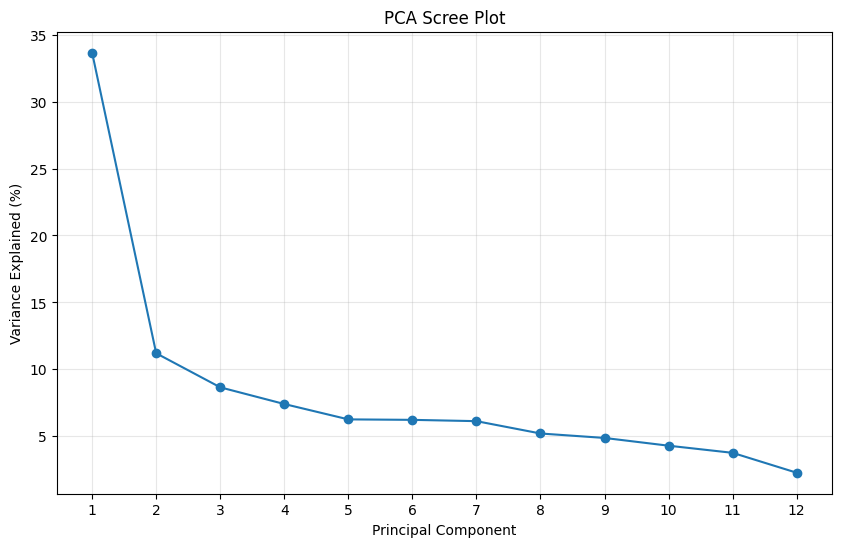

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(alpha=0.3)

plt.show()

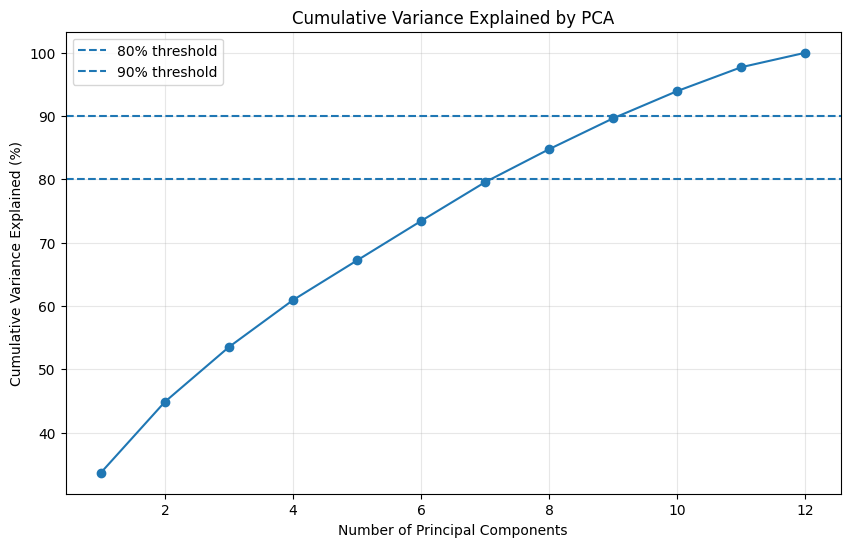

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(80, linestyle="--", label="80% threshold")
plt.axhline(90, linestyle="--", label="90% threshold")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained (%)")
plt.title("Cumulative Variance Explained by PCA")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
n_factors = np.argmax(cumulative_variance >= 0.80) + 1

print("Number of PCA factors selected:", n_factors)
print(
    "Cumulative variance explained:",
    round(cumulative_variance[n_factors - 1] * 100, 2),
    "%"
)

Number of PCA factors selected: 8
Cumulative variance explained: 84.77 %


In [20]:
pca = PCA(n_components=n_factors)

factor_scores = pca.fit_transform(X_standardized)

factor_names = [
    f"Factor_{i+1}" for i in range(n_factors)
]

factor_returns = pd.DataFrame(
    factor_scores,
    index=returns.index,
    columns=factor_names
)

print("Factor return matrix:")
factor_returns.head()

Factor return matrix:


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8
Date,,,,,,,,
2021-01-04,1.805196,2.670506,0.324943,0.272444,0.605217,-0.330421,-0.306653,0.001909
2021-01-05,0.028399,1.096668,-0.136310,-0.871453,0.733842,-0.871648,-0.228280,-0.745473
2021-01-06,-1.142149,-0.902690,-1.998118,0.551454,2.163358,-0.164382,1.091422,-0.346768
2021-01-07,-0.079268,-1.272145,-2.008232,1.189930,-0.337779,1.758742,1.461604,-0.712553
2021-01-08,3.849461,1.938980,0.080508,0.621731,2.355739,1.047546,-2.781884,1.428411


In [21]:
factor_variance = pd.DataFrame({
    "Factor": factor_names,
    "Variance Explained (%)": pca.explained_variance_ratio_ * 100,
    "Cumulative Variance (%)": np.cumsum(
        pca.explained_variance_ratio_
    ) * 100
})

factor_variance

,Factor,Variance Explained (%),Cumulative Variance (%)
0,Factor_1,33.646817,33.646817
1,Factor_2,11.203510,44.850327
2,Factor_3,8.660123,53.510450
3,Factor_4,7.413790,60.924240
4,Factor_5,6.266120,67.190359
5,Factor_6,6.231024,73.421383
6,Factor_7,6.134046,79.555429
7,Factor_8,5.212870,84.768298


In [22]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=factor_names
)

loadings

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6,Factor_7,Factor_8
Adani Ports,0.304302,-0.213945,-0.162721,0.150902,-0.348569,0.236832,-0.257077,-0.352279
Bharti Airtel,0.279172,-0.099613,-0.054442,0.278674,0.206559,0.311772,0.776724,-0.228806
HDFC Bank,0.326000,-0.190129,-0.188588,-0.367074,0.176299,-0.357211,0.018656,-0.164433
HUL,0.209297,0.091940,0.719405,-0.185653,0.170586,-0.103646,-0.152961,-0.477845
ICICI Bank,0.325966,-0.226381,-0.208905,-0.249517,0.176356,-0.417779,0.142986,0.056828
Infosys,0.277273,0.621838,-0.126851,-0.092354,-0.005535,0.017336,0.059022,0.043720
ITC,0.254991,-0.098753,0.513014,0.005345,-0.486912,-0.157128,0.304476,0.498073
L&T,0.347719,-0.095221,-0.213849,-0.048459,-0.079870,0.041489,-0.214462,0.355638
Maruti Suzuki,0.280672,-0.179941,0.191387,-0.060793,0.519979,0.533050,-0.263256,0.362212
Reliance,0.324737,-0.110947,-0.054610,0.025933,-0.427827,0.197236,-0.151976,-0.233945


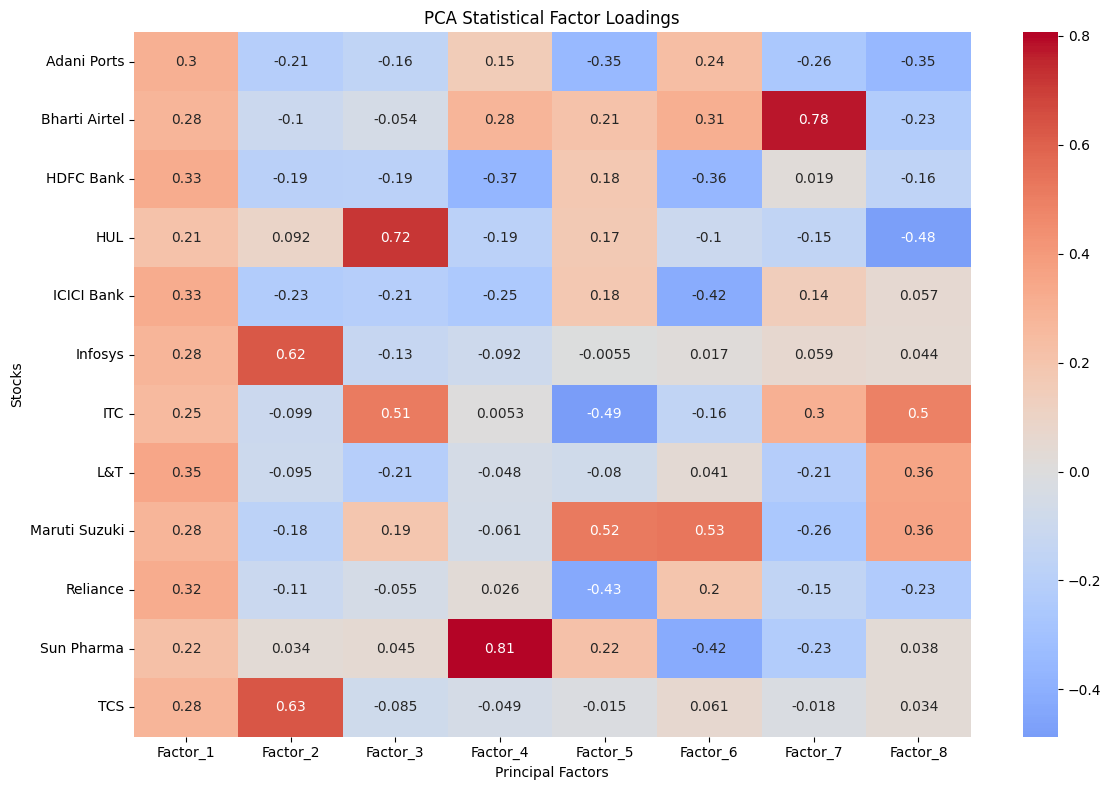

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Statistical Factor Loadings")
plt.xlabel("Principal Factors")
plt.ylabel("Stocks")

plt.tight_layout()
plt.show()

In [24]:
for factor in factor_names:
    print("\n", factor)
    print(
        loadings[factor]
        .sort_values(key=abs, ascending=False)
        .head(5)
    )


 Factor_1
L&T           0.347719
HDFC Bank     0.326000
ICICI Bank    0.325966
Reliance      0.324737
Adani Ports   0.304302
Name: Factor_1, dtype: float64

 Factor_2
TCS            0.630192
Infosys        0.621838
ICICI Bank    -0.226381
Adani Ports   -0.213945
HDFC Bank     -0.190129
Name: Factor_2, dtype: float64

 Factor_3
HUL              0.719405
ITC              0.513014
L&T             -0.213849
ICICI Bank      -0.208905
Maruti Suzuki    0.191387
Name: Factor_3, dtype: float64

 Factor_4
Sun Pharma       0.806486
HDFC Bank       -0.367074
Bharti Airtel    0.278674
ICICI Bank      -0.249517
HUL             -0.185653
Name: Factor_4, dtype: float64

 Factor_5
Maruti Suzuki    0.519979
ITC             -0.486912
Reliance        -0.427827
Adani Ports     -0.348569
Sun Pharma       0.217733
Name: Factor_5, dtype: float64

 Factor_6
Maruti Suzuki    0.533050
Sun Pharma      -0.424675
ICICI Bank      -0.417779
HDFC Bank       -0.357211
Bharti Airtel    0.311772
Name: Factor_6, dtype: f

PART 3 - FACTOR RETURN MODEL

In [25]:
reconstructed_standardized = pd.DataFrame(
    pca.inverse_transform(factor_scores),
    index=returns.index,
    columns=returns.columns
)

reconstructed_standardized.head()

,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Date,,,,,,,,,,,,
2021-01-04,-0.244832,0.079549,0.138161,0.990017,0.049058,2.067680,0.029558,0.295119,0.291752,0.001308,1.067176,2.117664
2021-01-05,-0.476237,-0.463660,0.705404,0.777162,0.425481,0.722359,-0.836805,-0.334107,-0.455447,-0.404390,-0.112141,0.667856
2021-01-06,-0.697511,1.356211,0.491181,-1.477043,0.698417,-0.641048,-2.092148,-0.447621,0.050274,-1.190038,0.351211,-0.817026
2021-01-07,1.163931,2.322383,-0.385392,-1.922182,-0.241067,-0.580723,-0.940234,-0.001557,-0.131038,0.691895,-0.369280,-0.649374
2021-01-08,0.476199,-0.624003,0.397206,0.962686,0.305104,2.108829,-0.612480,2.066467,3.742212,0.334042,2.179786,2.375619


In [26]:
idiosyncratic_standardized = (
    X_standardized - reconstructed_standardized
)

idiosyncratic_standardized.head()

,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Date,,,,,,,,,,,,
2021-01-04,-0.218702,0.114389,-0.614124,0.267544,0.464490,-0.692872,-0.226097,0.514854,-0.232560,0.091827,-0.105683,0.567810
2021-01-05,0.475105,-0.032359,-0.161518,-0.013536,0.266816,-0.461771,0.092014,-0.134825,0.008823,-0.489921,-0.081958,0.575595
2021-01-06,0.425191,0.121596,-0.817543,0.429303,0.510139,0.063384,-0.170519,0.763921,-0.323518,-0.679324,-0.193670,-0.137969
2021-01-07,0.240631,0.283725,0.153155,0.374930,-0.559664,-0.406108,-0.078940,1.160037,-0.458116,-0.829920,-0.131507,0.210714
2021-01-08,-0.264556,-0.096000,0.389958,-0.235816,-0.239624,0.365936,0.080296,-0.474373,0.214877,0.466494,0.126197,-0.322423


In [27]:
idiosyncratic_volatility = (
    idiosyncratic_standardized.std() * np.sqrt(252)
)

idiosyncratic_risk = pd.DataFrame({
    "Stock": idiosyncratic_volatility.index,
    "Annualized Idiosyncratic Volatility":
        idiosyncratic_volatility.values
})

idiosyncratic_risk.sort_values(
    "Annualized Idiosyncratic Volatility",
    ascending=False
)

,Stock,Annualized Idiosyncratic Volatility
9,Reliance,9.201943
7,L&T,9.132427
0,Adani Ports,8.051167
4,ICICI Bank,7.619507
2,HDFC Bank,7.605085
11,TCS,6.010384
5,Infosys,5.969422
3,HUL,3.664715
8,Maruti Suzuki,3.485005
6,ITC,2.780504


PART 4 - PORTFOLIO CONSTRUCTION

In [28]:
# Ensure weights correspond to current columns
portfolio_weights = pd.Series(
    1 / len(returns.columns),
    index=returns.columns
)

portfolio_returns = returns.dot(portfolio_weights)

portfolio_returns.name = "Portfolio"

portfolio_returns.head()

,Portfolio
Date,
2021-01-04,0.008347
2021-01-05,0.000784
2021-01-06,-0.004634
2021-01-07,0.000682
2021-01-08,0.017458


In [29]:
trading_days = 252

portfolio_mean_daily = portfolio_returns.mean()
portfolio_vol_daily = portfolio_returns.std()

portfolio_annual_return = portfolio_mean_daily * trading_days
portfolio_annual_volatility = portfolio_vol_daily * np.sqrt(trading_days)

print("Annualized Portfolio Return:",
      round(portfolio_annual_return * 100, 2), "%")

print("Annualized Portfolio Volatility:",
      round(portfolio_annual_volatility * 100, 2), "%")

Annualized Portfolio Return: 14.02 %
Annualized Portfolio Volatility: 13.75 %


In [30]:
risk_free_rate = 0.065

sharpe_ratio = (
    portfolio_annual_return - risk_free_rate
) / portfolio_annual_volatility

print("Annualized Portfolio Return:",
      round(portfolio_annual_return * 100, 2), "%")

print("Risk-Free Rate:",
      risk_free_rate * 100, "%")

print("Annualized Volatility:",
      round(portfolio_annual_volatility * 100, 2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio, 4))

Annualized Portfolio Return: 14.02 %
Risk-Free Rate: 6.5 %
Annualized Volatility: 13.75 %
Sharpe Ratio: 0.5468


In [31]:
individual_volatility = returns.std() * np.sqrt(252)

weighted_average_asset_volatility = (
    portfolio_weights * individual_volatility
).sum()

diversification_ratio = (
    weighted_average_asset_volatility /
    portfolio_annual_volatility
)

print(
    "Diversification Ratio:",
    round(diversification_ratio, 4)
)

Diversification Ratio: 1.722


PART 5 - PCA BASED RISK DECOMPOSITION

In [32]:
# Standardized covariance matrix
standardized_covariance = X_standardized.cov()

# PCA eigenvalues
eigenvalues = pca.explained_variance_

# Factor loading matrix
B = pca.components_.T

# Systematic covariance captured by selected PCA factors
systematic_covariance = (
    B @ np.diag(eigenvalues) @ B.T
)

systematic_covariance = pd.DataFrame(
    systematic_covariance,
    index=returns.columns,
    columns=returns.columns
)

systematic_covariance.head()

,Adani Ports,Bharti Airtel,HDFC Bank,HUL,ICICI Bank,Infosys,ITC,L&T,Maruti Suzuki,Reliance,Sun Pharma,TCS
Adani Ports,0.742773,0.322789,0.361081,0.155313,0.307658,0.154582,0.188087,0.474766,0.284186,0.670991,0.266846,0.177324
Bharti Airtel,0.322789,0.981781,0.290901,0.120148,0.351316,0.244210,0.263483,0.228530,0.317239,0.316541,0.243404,0.216910
HDFC Bank,0.361081,0.290901,0.770487,0.268974,0.740433,0.251984,0.188959,0.478570,0.283462,0.370613,0.147491,0.213769
HUL,0.155313,0.120148,0.268974,0.946706,0.154423,0.209826,0.352490,0.034583,0.314826,0.232476,0.167484,0.241695
ICICI Bank,0.307658,0.351316,0.740433,0.154423,0.769616,0.225326,0.287362,0.510324,0.283716,0.324602,0.232915,0.179924


In [33]:
residual_covariance = (
    standardized_covariance -
    systematic_covariance
)

# Numerical rounding / cleanup
residual_covariance = residual_covariance.clip(lower=0)

residual_variances = np.diag(residual_covariance)

residual_variances = pd.Series(
    residual_variances,
    index=returns.columns
)

residual_variances

,0
Adani Ports,0.257227
Bharti Airtel,0.018219
HDFC Bank,0.229513
HUL,0.053294
ICICI Bank,0.230384
Infosys,0.141405
ITC,0.030679
L&T,0.330957
Maruti Suzuki,0.048195
Reliance,0.336015


In [34]:
w = portfolio_weights.values.reshape(-1, 1)

systematic_variance = (
    w.T @ systematic_covariance.values @ w
).item()

idiosyncratic_variance = (
    np.sum(
        (portfolio_weights.values ** 2)
        * residual_variances.values
    )
)

total_standardized_variance = (
    systematic_variance +
    idiosyncratic_variance
)

systematic_risk_share = (
    systematic_variance /
    total_standardized_variance
)

idiosyncratic_risk_share = (
    idiosyncratic_variance /
    total_standardized_variance
)

print("Systematic variance:", systematic_variance)
print("Idiosyncratic variance:", idiosyncratic_variance)

print(
    "\nSystematic risk share:",
    round(systematic_risk_share * 100, 2),
    "%"
)

print(
    "Idiosyncratic risk share:",
    round(idiosyncratic_risk_share * 100, 2),
    "%"
)

Systematic variance: 0.3313905549941121
Idiosyncratic variance: 0.0126930847027222

Systematic risk share: 96.31 %
Idiosyncratic risk share: 3.69 %


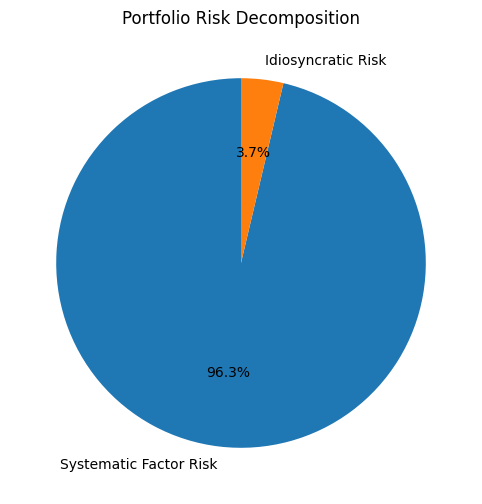

In [35]:
risk_decomposition = pd.Series({
    "Systematic Factor Risk": systematic_risk_share,
    "Idiosyncratic Risk": idiosyncratic_risk_share
})

plt.figure(figsize=(8, 6))

risk_decomposition.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Portfolio Risk Decomposition")
plt.ylabel("")

plt.show()

PART 6 - HISTORICAL VaR

In [36]:
confidence_levels = [0.95, 0.99]

historical_var = {}

for confidence in confidence_levels:
    percentile = np.quantile(
        portfolio_returns,
        1 - confidence
    )

    historical_var[confidence] = -percentile

historical_var_df = pd.DataFrame({
    "Confidence Level": ["95%", "99%"],
    "Historical VaR": [
        historical_var[0.95],
        historical_var[0.99]
    ]
})

historical_var_df

,Confidence Level,Historical VaR
0,95%,0.013314
1,99%,0.022469


In [37]:
expected_shortfall = {}

for confidence in confidence_levels:

    var_threshold = np.quantile(
        portfolio_returns,
        1 - confidence
    )

    tail_losses = portfolio_returns[
        portfolio_returns <= var_threshold
    ]

    expected_shortfall[confidence] = -tail_losses.mean()

es_df = pd.DataFrame({
    "Confidence Level": ["95%", "99%"],
    "Expected Shortfall": [
        expected_shortfall[0.95],
        expected_shortfall[0.99]
    ]
})

es_df

,Confidence Level,Expected Shortfall
0,95%,0.019248
1,99%,0.029671


In [38]:
risk_measure_df = pd.DataFrame({
    "Confidence": ["95%", "99%"],
    "Historical VaR": [
        historical_var[0.95],
        historical_var[0.99]
    ],
    "Expected Shortfall": [
        expected_shortfall[0.95],
        expected_shortfall[0.99]
    ]
})

risk_measure_df

,Confidence,Historical VaR,Expected Shortfall
0,95%,0.013314,0.019248
1,99%,0.022469,0.029671


PART 7 - PARAMETRIC VaR

In [39]:
mu_daily = portfolio_returns.mean()
sigma_daily = portfolio_returns.std()

parametric_var = {}

for confidence in confidence_levels:

    z = stats.norm.ppf(1 - confidence)

    var = -(mu_daily + z * sigma_daily)

    parametric_var[confidence] = var

parametric_var_df = pd.DataFrame({
    "Confidence Level": ["95%", "99%"],
    "Parametric VaR": [
        parametric_var[0.95],
        parametric_var[0.99]
    ]
})

parametric_var_df

,Confidence Level,Parametric VaR
0,95%,0.013694
1,99%,0.019598


PART 8 - MONTE CARLO VaR

In [40]:
np.random.seed(42)

n_simulations = 10000

simulated_returns = np.random.normal(
    loc=mu_daily,
    scale=sigma_daily,
    size=n_simulations
)

monte_carlo_var = {}

for confidence in confidence_levels:

    threshold = np.quantile(
        simulated_returns,
        1 - confidence
    )

    monte_carlo_var[confidence] = -threshold

monte_carlo_var

{0.95: np.float64(0.013780264986889192),
 0.99: np.float64(0.019547315681559815)}

In [41]:
monte_carlo_es = {}

for confidence in confidence_levels:

    threshold = np.quantile(
        simulated_returns,
        1 - confidence
    )

    tail = simulated_returns[
        simulated_returns <= threshold
    ]

    monte_carlo_es[confidence] = -tail.mean()

monte_carlo_es

{0.95: np.float64(0.0174233644350476), 0.99: np.float64(0.022807300493142835)}

In [42]:
comparison = pd.DataFrame({
    "Confidence": ["95%", "99%"],

    "Historical VaR": [
        historical_var[0.95],
        historical_var[0.99]
    ],

    "Parametric VaR": [
        parametric_var[0.95],
        parametric_var[0.99]
    ],

    "Monte Carlo VaR": [
        monte_carlo_var[0.95],
        monte_carlo_var[0.99]
    ],

    "Historical ES": [
        expected_shortfall[0.95],
        expected_shortfall[0.99]
    ],

    "Monte Carlo ES": [
        monte_carlo_es[0.95],
        monte_carlo_es[0.99]
    ]
})

comparison

,Confidence,Historical VaR,Parametric VaR,Monte Carlo VaR,Historical ES,Monte Carlo ES
0,95%,0.013314,0.013694,0.013780,0.019248,0.017423
1,99%,0.022469,0.019598,0.019547,0.029671,0.022807


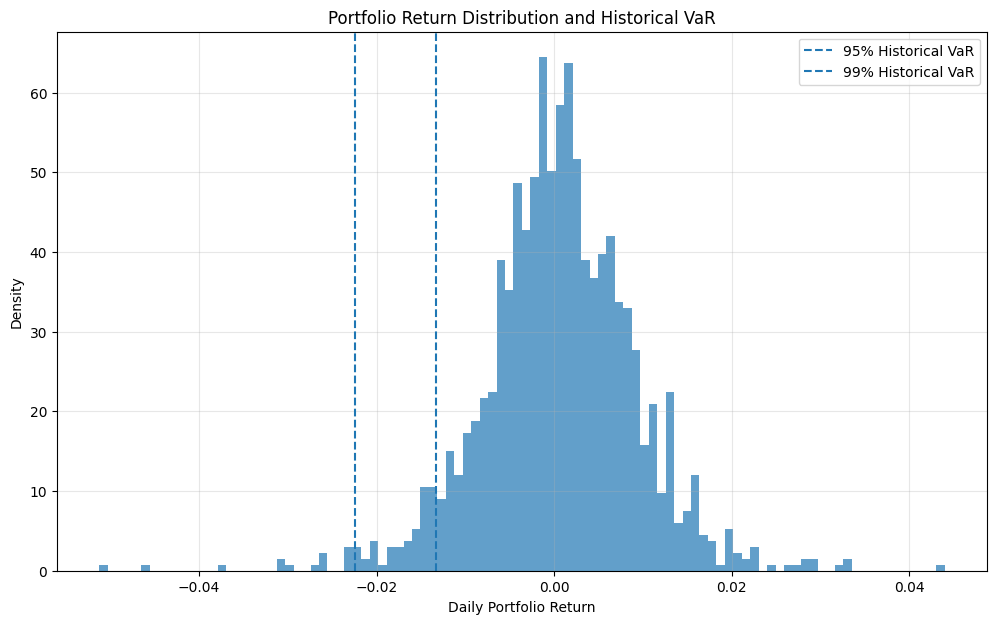

In [43]:
plt.figure(figsize=(12, 7))

plt.hist(
    portfolio_returns,
    bins=100,
    density=True,
    alpha=0.7
)

plt.axvline(
    -historical_var[0.95],
    linestyle="--",
    label="95% Historical VaR"
)

plt.axvline(
    -historical_var[0.99],
    linestyle="--",
    label="99% Historical VaR"
)

plt.title("Portfolio Return Distribution and Historical VaR")
plt.xlabel("Daily Portfolio Return")
plt.ylabel("Density")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

PART 9 - MAXIMUM DRAWDOWN

In [44]:
cumulative_wealth = (1 + portfolio_returns).cumprod()

running_max = cumulative_wealth.cummax()

drawdown = (
    cumulative_wealth / running_max
) - 1

maximum_drawdown = drawdown.min()

print(
    "Maximum Drawdown:",
    round(maximum_drawdown * 100, 2),
    "%"
)

Maximum Drawdown: -17.72 %


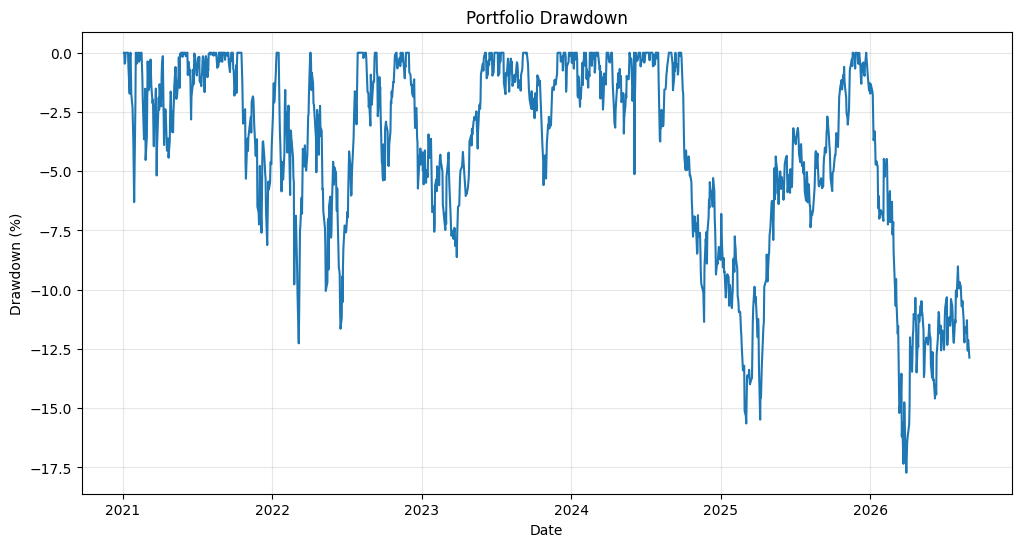

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown * 100
)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.grid(alpha=0.3)
plt.show()

PART 10 - VaR BACKTESTING

In [46]:
window = 252
confidence = 0.95

rolling_var = (
    portfolio_returns
    .rolling(window)
    .quantile(1 - confidence)
)

rolling_var = -rolling_var

backtest_df = pd.DataFrame({
    "Return": portfolio_returns,
    "VaR_95": rolling_var
}).dropna()

backtest_df["Breach"] = (
    backtest_df["Return"] < -backtest_df["VaR_95"]
)

print("Number of observations:", len(backtest_df))
print(
    "Number of VaR breaches:",
    backtest_df["Breach"].sum()
)

print(
    "Observed breach rate:",
    round(backtest_df["Breach"].mean() * 100, 2),
    "%"
)

print("Expected breach rate: 5%")

Number of observations: 1151
Number of VaR breaches: 65
Observed breach rate: 5.65 %
Expected breach rate: 5%


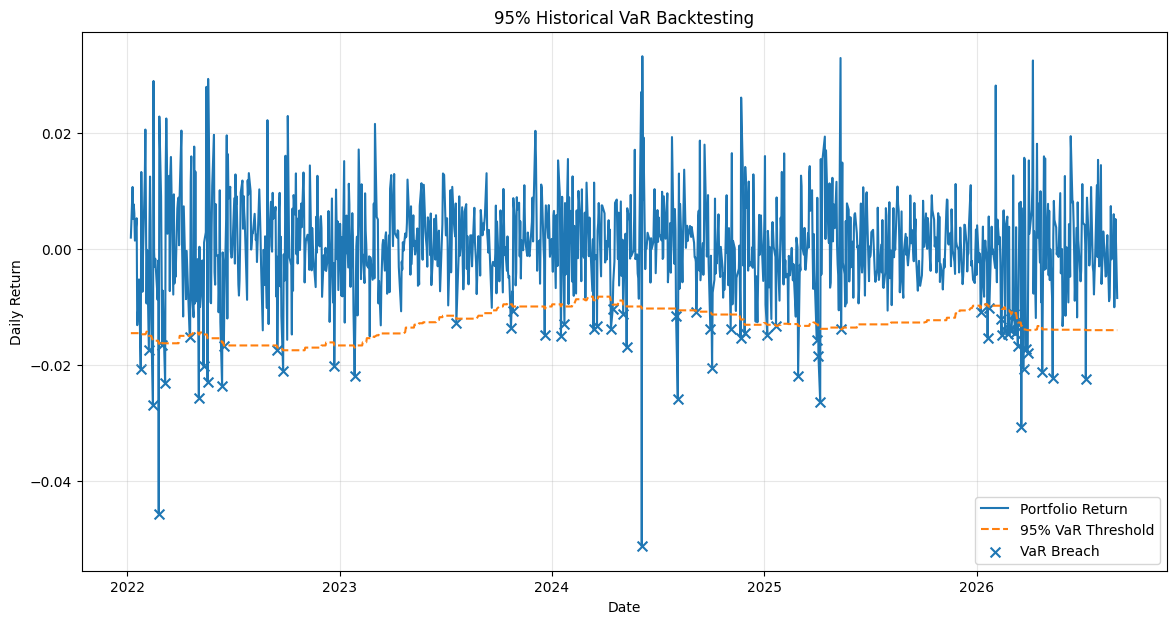

In [47]:
plt.figure(figsize=(14, 7))

plt.plot(
    backtest_df.index,
    backtest_df["Return"],
    label="Portfolio Return"
)

plt.plot(
    backtest_df.index,
    -backtest_df["VaR_95"],
    linestyle="--",
    label="95% VaR Threshold"
)

breaches = backtest_df[
    backtest_df["Breach"]
]

plt.scatter(
    breaches.index,
    breaches["Return"],
    marker="x",
    s=50,
    label="VaR Breach"
)

plt.title("95% Historical VaR Backtesting")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [48]:
def kupiec_test(breaches, total_observations, confidence=0.95):

    x = breaches
    n = total_observations

    p = 1 - confidence
    phat = x / n

    # Avoid log(0)
    phat = np.clip(phat, 1e-10, 1 - 1e-10)
    p = np.clip(p, 1e-10, 1 - 1e-10)

    log_likelihood_restricted = (
        (n - x) * np.log(1 - p)
        + x * np.log(p)
    )

    log_likelihood_unrestricted = (
        (n - x) * np.log(1 - phat)
        + x * np.log(phat)
    )

    LR_uc = -2 * (
        log_likelihood_restricted
        - log_likelihood_unrestricted
    )

    p_value = 1 - chi2.cdf(LR_uc, df=1)

    return LR_uc, p_value


breaches = int(backtest_df["Breach"].sum())
n_obs = len(backtest_df)

kupiec_lr, kupiec_pvalue = kupiec_test(
    breaches,
    n_obs,
    confidence=0.95
)

print("Kupiec LR statistic:", round(kupiec_lr, 4))
print("Kupiec p-value:", round(kupiec_pvalue, 4))

if kupiec_pvalue > 0.05:
    print(
        "Conclusion: Fail to reject correct unconditional coverage at the 5% level."
    )
else:
    print(
        "Conclusion: Reject correct unconditional coverage at the 5% level."
    )

Kupiec LR statistic: 0.9762
Kupiec p-value: 0.3231
Conclusion: Fail to reject correct unconditional coverage at the 5% level.


PART 11 - ROLLING FACTOR EXPOSURE

In [49]:
rolling_window = 252

rolling_factor_exposure = []

dates = returns.index[rolling_window:]

for i in range(
    rolling_window,
    len(returns),
    20
):

    window_data = returns.iloc[
        i - rolling_window:i
    ]

    window_standardized = (
        window_data - window_data.mean()
    ) / window_data.std()

    temp_pca = PCA(
        n_components=min(3, len(returns.columns))
    )

    temp_pca.fit(window_standardized)

    # Absolute exposure of each stock to first factor
    first_factor_loading = temp_pca.components_[0]

    rolling_factor_exposure.append({
        "Date": returns.index[i],
        "PC1_Mean_Abs_Loading":
            np.mean(np.abs(first_factor_loading)),
        "PC1_Max_Abs_Loading":
            np.max(np.abs(first_factor_loading))
    })

rolling_exposure_df = pd.DataFrame(
    rolling_factor_exposure
).set_index("Date")

rolling_exposure_df.head()

,PC1_Mean_Abs_Loading,PC1_Max_Abs_Loading
Date,,
2022-01-10,0.284504,0.351354
2022-02-08,0.285481,0.345859
2022-03-09,0.286810,0.331531
2022-04-07,0.286257,0.347169
2022-05-10,0.286968,0.345570


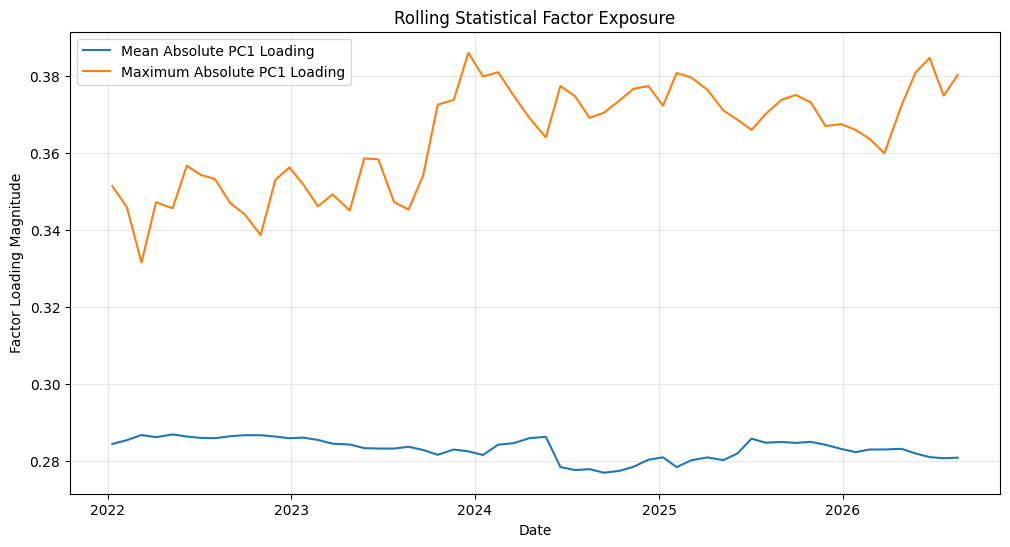

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_exposure_df[
        "PC1_Mean_Abs_Loading"
    ],
    label="Mean Absolute PC1 Loading"
)

plt.plot(
    rolling_exposure_df[
        "PC1_Max_Abs_Loading"
    ],
    label="Maximum Absolute PC1 Loading"
)

plt.title("Rolling Statistical Factor Exposure")
plt.xlabel("Date")
plt.ylabel("Factor Loading Magnitude")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

PART 12 - FINAL RISK DASHBOARD

In [51]:
final_results = pd.DataFrame({
    "Metric": [
        "Annualized Portfolio Return",
        "Annualized Portfolio Volatility",
        "Sharpe Ratio",
        "Diversification Ratio",
        "95% Historical VaR",
        "99% Historical VaR",
        "95% Expected Shortfall",
        "99% Expected Shortfall",
        "95% Parametric VaR",
        "99% Parametric VaR",
        "95% Monte Carlo VaR",
        "99% Monte Carlo VaR",
        "Maximum Drawdown",
        "Number of PCA Factors",
        "Variance Explained by Selected Factors",
        "Systematic Risk Share",
        "Idiosyncratic Risk Share",
        "95% VaR Breach Rate",
        "Kupiec Test p-value"
    ],

    "Value": [
        portfolio_annual_return,
        portfolio_annual_volatility,
        sharpe_ratio,
        diversification_ratio,
        historical_var[0.95],
        historical_var[0.99],
        expected_shortfall[0.95],
        expected_shortfall[0.99],
        parametric_var[0.95],
        parametric_var[0.99],
        monte_carlo_var[0.95],
        monte_carlo_var[0.99],
        maximum_drawdown,
        n_factors,
        cumulative_variance[n_factors - 1],
        systematic_risk_share,
        idiosyncratic_risk_share,
        backtest_df["Breach"].mean(),
        kupiec_pvalue
    ]
})

final_results

,Metric,Value
0,Annualized Portfolio Return,0.140195
1,Annualized Portfolio Volatility,0.137526
2,Sharpe Ratio,0.546771
3,Diversification Ratio,1.721966
4,95% Historical VaR,0.013314
5,99% Historical VaR,0.022469
6,95% Expected Shortfall,0.019248
7,99% Expected Shortfall,0.029671
8,95% Parametric VaR,0.013694
9,99% Parametric VaR,0.019598


In [52]:
percentage_metrics = [
    "Annualized Portfolio Return",
    "Annualized Portfolio Volatility",
    "95% Historical VaR",
    "99% Historical VaR",
    "95% Expected Shortfall",
    "99% Expected Shortfall",
    "95% Parametric VaR",
    "99% Parametric VaR",
    "95% Monte Carlo VaR",
    "99% Monte Carlo VaR",
    "Maximum Drawdown",
    "Variance Explained by Selected Factors",
    "Systematic Risk Share",
    "Idiosyncratic Risk Share",
    "95% VaR Breach Rate"
]

display_results = final_results.copy()

display_results.loc[
    display_results["Metric"].isin(percentage_metrics),
    "Value"
] = (
    display_results.loc[
        display_results["Metric"].isin(percentage_metrics),
        "Value"
    ].astype(float) * 100
)

display_results

,Metric,Value
0,Annualized Portfolio Return,14.019530
1,Annualized Portfolio Volatility,13.752622
2,Sharpe Ratio,0.546771
3,Diversification Ratio,1.721966
4,95% Historical VaR,1.331390
5,99% Historical VaR,2.246884
6,95% Expected Shortfall,1.924763
7,99% Expected Shortfall,2.967136
8,95% Parametric VaR,1.369359
9,99% Parametric VaR,1.959761


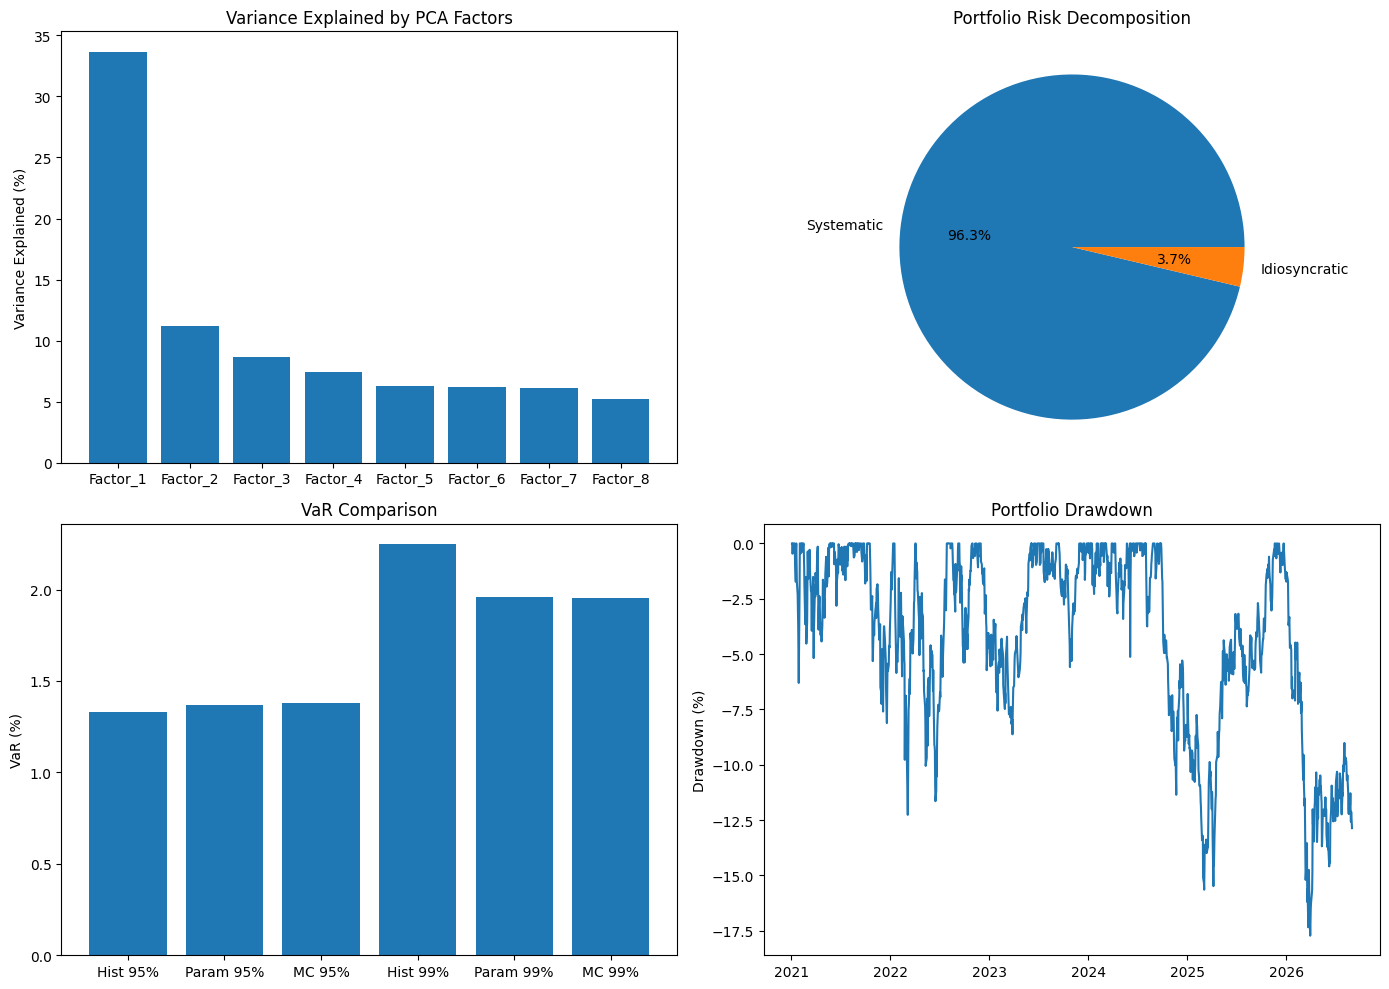

In [53]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

# 1. PCA variance
axes[0, 0].bar(
    factor_variance["Factor"],
    factor_variance["Variance Explained (%)"]
)

axes[0, 0].set_title(
    "Variance Explained by PCA Factors"
)

axes[0, 0].set_ylabel("Variance Explained (%)")


# 2. Risk decomposition
axes[0, 1].pie(
    [systematic_risk_share, idiosyncratic_risk_share],
    labels=[
        "Systematic",
        "Idiosyncratic"
    ],
    autopct="%1.1f%%"
)

axes[0, 1].set_title(
    "Portfolio Risk Decomposition"
)


# 3. VaR comparison
var_labels = [
    "Hist 95%",
    "Param 95%",
    "MC 95%",
    "Hist 99%",
    "Param 99%",
    "MC 99%"
]

var_values = [
    historical_var[0.95],
    parametric_var[0.95],
    monte_carlo_var[0.95],
    historical_var[0.99],
    parametric_var[0.99],
    monte_carlo_var[0.99]
]

axes[1, 0].bar(
    var_labels,
    np.array(var_values) * 100
)

axes[1, 0].set_title(
    "VaR Comparison"
)

axes[1, 0].set_ylabel("VaR (%)")


# 4. Drawdown
axes[1, 1].plot(
    drawdown.index,
    drawdown * 100
)

axes[1, 1].set_title(
    "Portfolio Drawdown"
)

axes[1, 1].set_ylabel("Drawdown (%)")

plt.tight_layout()
plt.show()

In [54]:
summary_stats.to_csv(
    "stock_risk_summary.csv"
)

loadings.to_csv(
    "pca_factor_loadings.csv"
)

factor_variance.to_csv(
    "pca_factor_variance.csv",
    index=False
)

comparison.to_csv(
    "var_es_comparison.csv",
    index=False
)

display_results.to_csv(
    "final_risk_results.csv",
    index=False
)

weights_df.to_csv(
    "portfolio_weights.csv",
    index=False
)

print("All result files saved successfully.")

All result files saved successfully.


PART 13 - EXPORT RESULTS

In [55]:
prices.to_csv("stock_prices.csv")
returns.to_csv("stock_returns.csv")
factor_returns.to_csv("pca_factor_returns.csv")

In [56]:
from google.colab import files

files.download("final_risk_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
files.download("pca_factor_loadings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
files.download("var_es_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>